<a href="https://colab.research.google.com/github/aryan-327/IML-LAB/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Objective

To construct a Decision Tree using ID3 algorithm by calculating entropy and information gain, and to identify the best attribute for classification.

##Method Used

We used ID3 (Iterative Dichotomiser 3) algorithm.

Steps:
Compute entropy of dataset.
Calculate information gain for each attribute.
Select attribute with highest IG as root.
Split dataset based on that attribute.
Repeat recursively until:
All data in node belongs to same class
No attributes left

In [ ]:
import pandas as pd
import math

# Dataset
data = pd.DataFrame({
    'A1': ['T','T','T','F','F','F'],
    'A2': ['T','T','F','F','T','T'],
    'Class': ['+','+','-','+','-','-']
})

def entropy(col):
    values = col.value_counts(normalize=True)
    return -sum(p * math.log2(p) for p in values)

def info_gain(data, attr, target='Class'):
    total_entropy = entropy(data[target])

    values = data[attr].unique()
    weighted_entropy = 0

    for v in values:
        subset = data[data[attr] == v]
        weighted_entropy += (len(subset)/len(data)) * entropy(subset[target])

    return total_entropy - weighted_entropy

# Calculate IG
print("Information Gain:")
for col in ['A1','A2']:
    print(col, ":", round(info_gain(data, col), 3))

# Simple tree representation
def build_tree(data, attrs):
    if len(data['Class'].unique()) == 1:
        return data['Class'].iloc[0]

    if not attrs:
        return data['Class'].mode()[0]

    gains = {attr: info_gain(data, attr) for attr in attrs}
    best_attr = max(gains, key=gains.get)

    tree = {best_attr: {}}

    for val in data[best_attr].unique():
        subset = data[data[best_attr] == val]
        subtree = build_tree(subset, [a for a in attrs if a != best_attr])
        tree[best_attr][val] = subtree

    return tree

tree = build_tree(data, ['A1','A2'])
print("\nDecision Tree:")
print(tree)

Information Gain:
A1 : 0.082
A2 : 0.0

Decision Tree:
{'A1': {'T': {'A2': {'T': '+', 'F': '-'}}, 'F': {'A2': {'F': '+', 'T': '-'}}}}


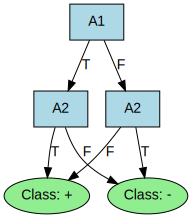

In [ ]:
import graphviz

def add_nodes_edges(tree, dot=None, parent_name=None, edge_label=''):
    if dot is None:
        dot = graphviz.Digraph(comment='Decision Tree', graph_attr={'rankdir': 'TB'})
        dot.node_attr.update(shape='box', style='filled', fillcolor='lightblue', fontname='Helvetica')
        dot.edge_attr.update(fontname='Helvetica')

    if isinstance(tree, dict):
        node_name = list(tree.keys())[0]
        current_node_id = str(id(tree))
        dot.node(current_node_id, node_name)
        if parent_name is not None:
            dot.edge(parent_name, current_node_id, label=edge_label)

        for value, subtree in tree[node_name].items():
            add_nodes_edges(subtree, dot, current_node_id, str(value))
    else:
        # Leaf node
        leaf_id = str(id(tree))
        dot.node(leaf_id, f'Class: {tree}', shape='ellipse', fillcolor='lightgreen')
        if parent_name is not None:
            dot.edge(parent_name, leaf_id, label=edge_label)

    return dot

# Assuming 'tree' is the decision tree dictionary generated previously
dot = add_nodes_edges(tree)
display(dot)

##Interpretation
Initial entropy = 1 (maximum uncertainty)
Attribute A1 has higher information gain than A2
Hence, A1 is chosen as root node
Further splits using A2 perfectly classify data

Dataset is clearly separable using 2 attributes.

##Conclusion
Decision Tree was successfully constructed using ID3.
Best splitting attribute: A1
Final tree classifies all instances correctly.

Key points:

ID3 uses Information Gain
Reduces entropy step-by-step
Produces an interpretable model

Hence, ID3 is effective for small categorical datasets.